### Load the data

In [5]:
# load the full modeling dataframe with keys
import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = Path("../data/clean/daily_stock_optimal_bucket_modeling_with_fred.parquet")
df = pd.read_parquet(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

print(df.shape)
print(df[["symbol", "date", "optimal_bucket"]].tail())

(41266, 88)
      symbol       date optimal_bucket
41261    WMT 2024-12-24         ATM_30
41262    WMT 2024-12-26         ATM_30
41263    WMT 2024-12-27         ATM_30
41264    WMT 2024-12-30         ATM_30
41265    WMT 2024-12-31         ATM_30


### Class distribution before changes

In [6]:
# Check current bucket distribution before change
print("Original optimal_bucket distribution:")
print(df["optimal_bucket"].value_counts())
# Replace selected bucket labels
bucket_map = {
    "OTM10_60": "OTM10_60_90",
    "OTM10_90": "OTM10_60_90",
    "OTM5_60": "OTM5_60_90",
    "OTM5_90": "OTM5_60_90"
}

df["optimal_bucket"] = df["optimal_bucket"].replace(bucket_map)

# Check updated distribution
print("\nUpdated optimal_bucket distribution:")
print(df["optimal_bucket"].value_counts())

Original optimal_bucket distribution:
optimal_bucket
ATM_90      15324
ATM_60       6470
ATM_30       4893
OTM5_30      3813
OTM10_30     3463
OTM5_60      2602
OTM10_90     2580
OTM5_90      1367
OTM10_60      754
Name: count, dtype: int64

Updated optimal_bucket distribution:
optimal_bucket
ATM_90         15324
ATM_60          6470
ATM_30          4893
OTM5_60_90      3969
OTM5_30         3813
OTM10_30        3463
OTM10_60_90     3334
Name: count, dtype: int64


### Encode Target variable

In [4]:
# encode the target and prepare features
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
df["target"] = target_encoder.fit_transform(df["optimal_bucket"])

print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

{'ATM_30': np.int64(0), 'ATM_60': np.int64(1), 'ATM_90': np.int64(2), 'OTM10_30': np.int64(3), 'OTM10_60_90': np.int64(4), 'OTM5_30': np.int64(5), 'OTM5_60_90': np.int64(6)}


### Train/test/Split

In [4]:
# Split by date before building sequences
train_df = df[df["date"] < "2022-01-01"].copy()
val_df = df[(df["date"] >= "2022-01-01") & (df["date"] < "2024-01-01")].copy()
test_df = df[df["date"] >= "2024-01-01"].copy()

print(train_df.shape, val_df.shape, test_df.shape)

(33736, 89) (5010, 89) (2520, 89)


In [5]:
# ---------------------------------------------
# Feature selection on TRAIN ONLY
# ---------------------------------------------
exclude_cols = [
    "symbol",
    "date",
    "fiscalDateEnding",
    "optimal_bucket",
    "target"
]

X_rf = train_df.drop(columns=[c for c in exclude_cols if c in train_df.columns]).copy()
X_rf = X_rf.select_dtypes(include=["number"]).copy()
y_rf = train_df["target"].copy()

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)

rf.fit(X_rf, y_rf)

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_rf.columns
).sort_values(ascending=False)

top_35_features = feature_importance.head(35)

print("Top 35 features:")

Top 35 features:


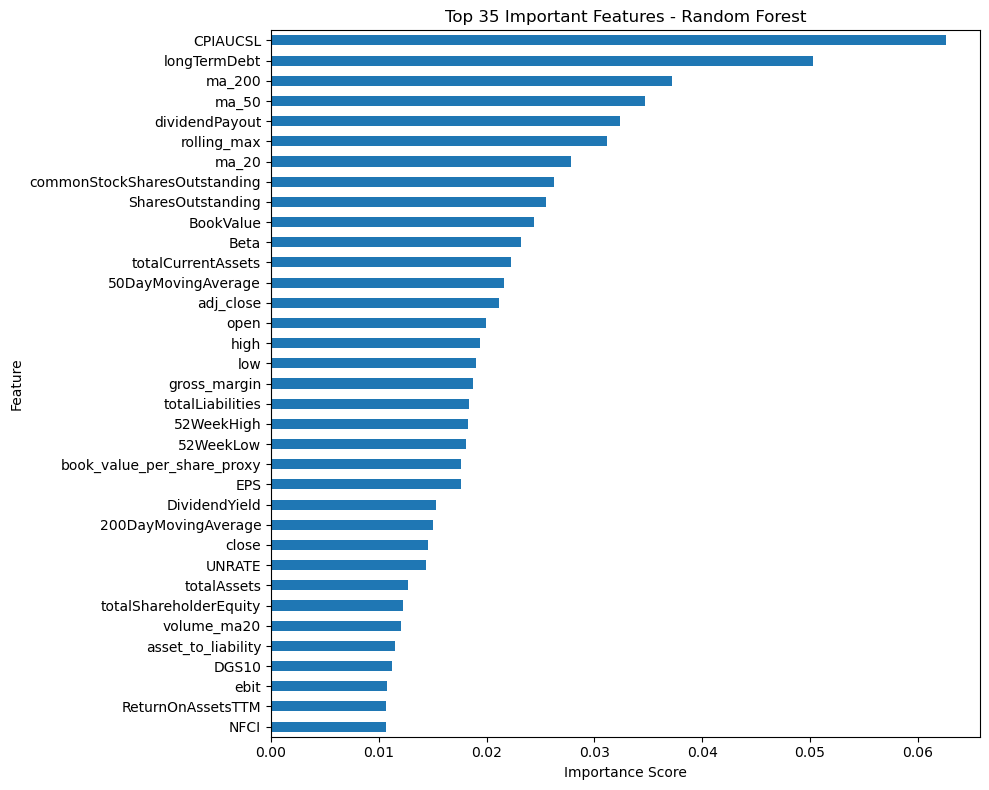

In [6]:
# --------------------------------------------------
# Plot top 35 features
# --------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
top_35_features.sort_values().plot(kind="barh")
plt.title("Top 35 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [7]:
keep_cols = ["symbol", "date", "target"] + top_35_features.index.tolist()

train_df = train_df[keep_cols].copy()
val_df = val_df[keep_cols].copy()
test_df = test_df[keep_cols].copy()

feature_cols = top_35_features.index.tolist()

### Standard scaling

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_df[feature_cols])

train_df[feature_cols] = scaler.transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

### Prepare input sequences for the model

In [ ]:
# Build rolling sequences per symbol ( use past 30 days to predict the label on day 30)

SEQ_LEN = 50

def build_sequences(panel_df, feature_cols, target_col="target", seq_len=50):
    X_seq = []
    y_seq = []

    for sym, grp in panel_df.groupby("symbol"):
        grp = grp.sort_values("date").reset_index(drop=True)

        X_vals = grp[feature_cols].values
        y_vals = grp[target_col].values

        if len(grp) < seq_len:
            continue

        for i in range(seq_len - 1, len(grp)):
            X_seq.append(X_vals[i - seq_len + 1:i + 1])  # fixed: include index i
            y_seq.append(y_vals[i])

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.int64)

In [10]:
# Now create train/val/test sequences

X_train_seq, y_train_seq = build_sequences(train_df, feature_cols, seq_len=SEQ_LEN)
X_val_seq, y_val_seq = build_sequences(val_df, feature_cols, seq_len=SEQ_LEN)
X_test_seq, y_test_seq = build_sequences(test_df, feature_cols, seq_len=SEQ_LEN)

print("Train sequences:", X_train_seq.shape, y_train_seq.shape)
print("Val sequences:", X_val_seq.shape, y_val_seq.shape)
print("Test sequences:", X_test_seq.shape, y_test_seq.shape)

Train sequences: (33246, 50, 35) (33246,)
Val sequences: (4520, 50, 35) (4520,)
Test sequences: (2030, 50, 35) (2030,)


### Imbalance corrections

In [11]:
# optionally rebalnce train split

train_seq_df = pd.DataFrame({"target": y_train_seq})
print(train_seq_df["target"].value_counts().sort_index())

target
0     4298
1     6141
2    12459
3     3072
4      713
5     3630
6     2933
Name: count, dtype: int64


In [12]:
target_counts = {
    2: 9000,
    4: 1500,
    6: 2200
}

balanced_indices = []

for cls, idx in train_seq_df.groupby("target").groups.items():
    idx = np.array(list(idx))
    n_current = len(idx)

    if cls in target_counts:
        n_target = target_counts[cls]

        if n_target < n_current:
            idx_bal = np.random.RandomState(42).choice(idx, size=n_target, replace=False)
        elif n_target > n_current:
            idx_bal = np.random.RandomState(42).choice(idx, size=n_target, replace=True)
        else:
            idx_bal = idx
    else:
        idx_bal = idx

    balanced_indices.extend(idx_bal.tolist())

balanced_indices = np.array(balanced_indices)

X_train_seq_bal = X_train_seq[balanced_indices]
y_train_seq_bal = y_train_seq[balanced_indices]

print(X_train_seq_bal.shape, y_train_seq_bal.shape)
print(pd.Series(y_train_seq_bal).value_counts().sort_index())

(29841, 50, 35) (29841,)
0    4298
1    6141
2    9000
3    3072
4    1500
5    3630
6    2200
Name: count, dtype: int64


In [13]:
# Compute class weights
from sklearn.utils.class_weight import compute_class_weight

classes_bal = np.sort(np.unique(y_train_seq_bal))
class_weights_bal = compute_class_weight(
    class_weight="balanced",
    classes=classes_bal,
    y=y_train_seq_bal
)

class_weight_dict_bal = dict(zip(classes_bal, class_weights_bal))
print(class_weight_dict_bal)

{np.int64(0): np.float64(0.99185667752443), np.int64(1): np.float64(0.6941866145578895), np.int64(2): np.float64(0.4736666666666667), np.int64(3): np.float64(1.3876953125), np.int64(4): np.float64(2.842), np.int64(5): np.float64(1.1743801652892563), np.int64(6): np.float64(1.9377272727272727)}


In [14]:
# Create pytorch datasets

import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "past_values": self.X[idx],
            "target": self.y[idx]
        }

train_dataset = TimeSeriesDataset(X_train_seq_bal, y_train_seq_bal)
val_dataset = TimeSeriesDataset(X_val_seq, y_val_seq)
test_dataset = TimeSeriesDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)  # fixed: preserve temporal order
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [15]:
# Define define PatchTST classification model

import torch
import torch.nn as nn
from transformers import PatchTSTConfig, PatchTSTForClassification

num_classes = len(np.unique(y_train_seq_bal))
num_input_channels = X_train_seq_bal.shape[2]

config = PatchTSTConfig(
    num_input_channels=num_input_channels,
    context_length=SEQ_LEN,
    patch_length=5,
    stride=5,
    num_targets=num_classes,
    d_model=64,
    num_attention_heads=4,
    num_hidden_layers=3,
    ffn_dim=128,
    dropout=0.1,
    head_dropout=0.1,
    norm_type="batchnorm"
)

model = PatchTSTForClassification(config)

In [16]:
# training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

weights_tensor = torch.tensor(
    [class_weight_dict_bal[c] for c in range(num_classes)],
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [17]:
import torch
import torch.nn as nn
from sklearn.metrics import f1_score

def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds, targets = [], []

    with torch.no_grad():
        for batch in loader:
            x = batch["past_values"].to(device)
            y = batch["target"].to(device)

            outputs = model(past_values=x)
            logits = outputs.prediction_logits

            loss = criterion(logits, y)
            total_loss += loss.item()

            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            targets.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(targets, preds, average="macro", zero_division=0)
    return avg_loss, macro_f1

In [18]:
def train_patchtst_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=12,
    patience=3
):
    best_val_f1 = -1
    best_state = None
    patience_counter = 0

    train_losses, val_losses = [], []
    train_f1s, val_f1s = [], []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        train_preds, train_targets = [], []

        for batch in train_loader:
            x = batch["past_values"].to(device)
            y = batch["target"].to(device)

            optimizer.zero_grad()

            outputs = model(past_values=x)
            logits = outputs.prediction_logits

            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            train_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
            train_targets.extend(y.cpu().numpy())

        avg_train_loss = total_train_loss / len(train_loader)
        train_macro_f1 = f1_score(train_targets, train_preds, average="macro", zero_division=0)

        val_loss, val_macro_f1 = evaluate_model(model, val_loader, criterion, device)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_f1s.append(train_macro_f1)
        val_f1s.append(val_macro_f1)

        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    return {
        "best_val_f1": best_val_f1,
        "best_state": best_state,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_f1s": train_f1s,
        "val_f1s": val_f1s,
    }

In [19]:
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import PatchTSTConfig, PatchTSTForClassification

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(np.unique(y_train_seq_bal))
num_input_channels = X_train_seq_bal.shape[2]

In [21]:
def make_loaders(batch_size):
    train_dataset = TimeSeriesDataset(X_train_seq_bal, y_train_seq_bal)
    val_dataset = TimeSeriesDataset(X_val_seq, y_val_seq)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)  # fixed: preserve temporal order
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
    return train_loader, val_loader

In [22]:
def objective(trial):
    d_model = trial.suggest_categorical("d_model", [32, 64])
    num_attention_heads = trial.suggest_categorical("num_attention_heads", [2, 4])
    num_hidden_layers = trial.suggest_int("num_hidden_layers", 2, 4)
    ffn_dim = trial.suggest_categorical("ffn_dim", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.1, 0.4)
    head_dropout = trial.suggest_float("head_dropout", 0.1, 0.4)
    patch_length = trial.suggest_categorical("patch_length", [4, 5, 6, 10])
    stride = trial.suggest_categorical("stride", [2, 4, 5])
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32])

    # make sure d_model divisible by heads
    if d_model % num_attention_heads != 0:
        raise optuna.exceptions.TrialPruned()

    config = PatchTSTConfig(
        num_input_channels=num_input_channels,
        context_length=SEQ_LEN,
        patch_length=patch_length,
        stride=stride,
        num_targets=num_classes,
        d_model=d_model,
        num_attention_heads=num_attention_heads,
        num_hidden_layers=num_hidden_layers,
        ffn_dim=ffn_dim,
        dropout=dropout,
        head_dropout=head_dropout,
        norm_type="batchnorm"
    )

    model = PatchTSTForClassification(config).to(device)

    weights_tensor = torch.tensor(
        [class_weight_dict_bal[c] for c in range(num_classes)],
        dtype=torch.float32,
        device=device
    )

    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_loader, val_loader = make_loaders(batch_size)

    result = train_patchtst_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=10,
        patience=3
    )

    return result["best_val_f1"]

In [24]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=7)

print("Best trial score:", study.best_value)
print("Best params:")
print(study.best_params)

[I 2026-03-24 23:52:52,037] A new study created in memory with name: no-name-ebf4f295-d78e-429f-a847-692b83b413c7
[I 2026-03-25 00:14:11,363] Trial 0 finished with value: 0.17526645521120926 and parameters: {'d_model': 64, 'num_attention_heads': 4, 'num_hidden_layers': 3, 'ffn_dim': 64, 'dropout': 0.29388421471928516, 'head_dropout': 0.38486833326405007, 'patch_length': 6, 'stride': 4, 'lr': 0.00038551664572193905, 'weight_decay': 0.0016156764403685026, 'batch_size': 32}. Best is trial 0 with value: 0.17526645521120926.
[I 2026-03-25 00:49:13,859] Trial 1 finished with value: 0.18069577659673566 and parameters: {'d_model': 32, 'num_attention_heads': 2, 'num_hidden_layers': 2, 'ffn_dim': 256, 'dropout': 0.3991831485199144, 'head_dropout': 0.2535504754334585, 'patch_length': 4, 'stride': 2, 'lr': 0.004015152900527756, 'weight_decay': 0.0027252494230739477, 'batch_size': 32}. Best is trial 1 with value: 0.18069577659673566.
[I 2026-03-25 02:49:09,800] Trial 2 finished with value: 0.181711

Best trial score: 0.18171165591246705
Best params:
{'d_model': 64, 'num_attention_heads': 2, 'num_hidden_layers': 4, 'ffn_dim': 64, 'dropout': 0.10749770846451041, 'head_dropout': 0.3397147577004082, 'patch_length': 4, 'stride': 5, 'lr': 0.0004197788900575046, 'weight_decay': 0.00028061759218686783, 'batch_size': 32}


In [25]:
best_params = study.best_params

config = PatchTSTConfig(
    num_input_channels=num_input_channels,
    context_length=SEQ_LEN,
    patch_length=best_params["patch_length"],
    stride=best_params["stride"],
    num_targets=num_classes,
    d_model=best_params["d_model"],
    num_attention_heads=best_params["num_attention_heads"],
    num_hidden_layers=best_params["num_hidden_layers"],
    ffn_dim=best_params["ffn_dim"],
    dropout=best_params["dropout"],
    head_dropout=best_params["head_dropout"],
    norm_type="batchnorm"
)

best_model = PatchTSTForClassification(config).to(device)

weights_tensor = torch.tensor(
    [class_weight_dict_bal[c] for c in range(num_classes)],
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.AdamW(
    best_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=False)  # fixed: preserve temporal order
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

result = train_patchtst_model(
    model=best_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=15,
    patience=4
)

best_model.load_state_dict(result["best_state"])

<All keys matched successfully>

In [26]:
# Load best tuned model state and evaluate on test
best_model.load_state_dict(result["best_state"])

test_loss, test_macro_f1 = evaluate_model(best_model, test_loader, criterion, device)

print("Best Val Macro F1:", result["best_val_f1"])
print("Test Loss:", test_loss)
print("Test Macro F1:", test_macro_f1)

Best Val Macro F1: 0.16883233115728716
Test Loss: 3.217858411371708
Test Macro F1: 0.133425706849469


In [27]:
# save the best model
from pathlib import Path
import torch

MODEL_DIR = Path("../saved_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "patchtst_best_model_with_fred.pth"

torch.save({
    "model_state_dict": best_model.state_dict(),
    "best_params": best_params,
    "feature_cols": feature_cols,
    "seq_len": SEQ_LEN,
    "num_classes": num_classes,
    "target_classes": list(target_encoder.classes_)
}, MODEL_PATH)

print("Saved model to:", MODEL_PATH)

Saved model to: ../saved_models/patchtst_best_model_with_fred.pth


In [28]:
MODEL_PATH = "../saved_models/patchtst_full_model.pt"

torch.save(best_model, MODEL_PATH)

print("Full model saved at:", MODEL_PATH)

Full model saved at: ../saved_models/patchtst_full_model.pt


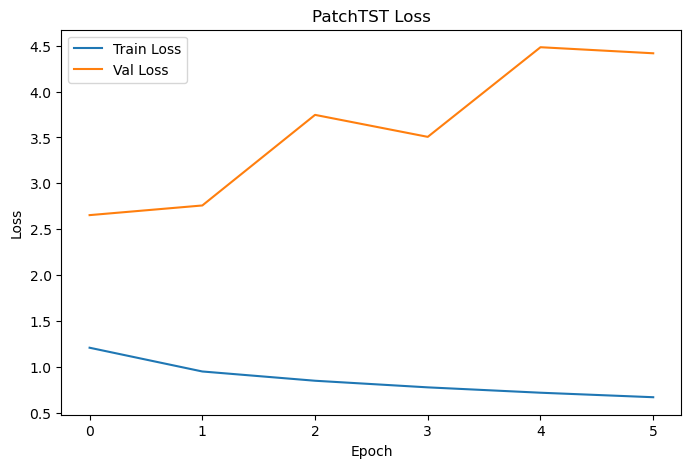

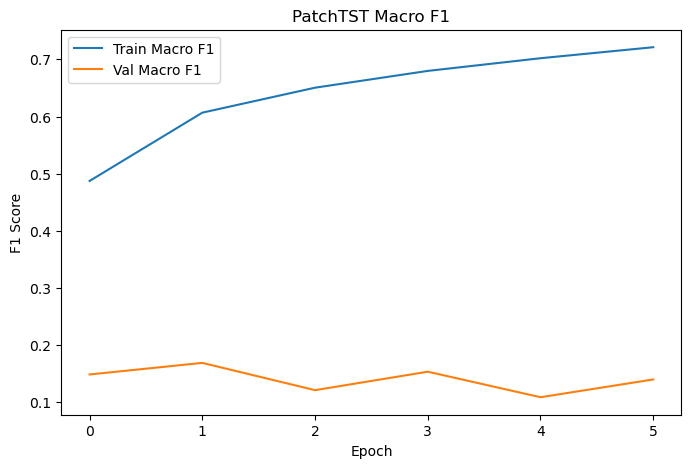

In [29]:
# Plot training curves
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(result["train_losses"], label="Train Loss")
plt.plot(result["val_losses"], label="Val Loss")
plt.legend()
plt.title("PatchTST Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(result["train_f1s"], label="Train Macro F1")
plt.plot(result["val_f1s"], label="Val Macro F1")
plt.legend()
plt.title("PatchTST Macro F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.show()

In [30]:
# helper to collect probabilities
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report
import numpy as np
import torch

def collect_probs_targets(model, loader, device):
    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            x = batch["past_values"].to(device)
            y = batch["target"].to(device)

            outputs = model(past_values=x)
            logits = outputs.prediction_logits

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    return np.array(all_probs), np.array(all_preds), np.array(all_targets)

In [31]:
# baseline validation metrics
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report

y_val_prob, y_val_pred_base, y_val_true = collect_probs_targets(best_model, val_loader, device)

print("=== Baseline Validation Metrics ===")
print("Accuracy:", accuracy_score(y_val_true, y_val_pred_base))
print("Macro F1:", f1_score(y_val_true, y_val_pred_base, average="macro", zero_division=0))
print("Balanced Accuracy:", balanced_accuracy_score(y_val_true, y_val_pred_base))

print("\nClassification Report:")
print(classification_report(y_val_true, y_val_pred_base, zero_division=0))

=== Baseline Validation Metrics ===
Accuracy: 0.3694690265486726
Macro F1: 0.16883233115728716
Balanced Accuracy: 0.20967200894812463

Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.06      0.10       393
           1       0.00      0.01      0.00       159
           2       0.68      0.56      0.62      1891
           3       0.00      0.00      0.00       152
           4       0.42      0.07      0.12      1232
           5       0.00      0.00      0.00        43
           6       0.22      0.77      0.34       650

    accuracy                           0.37      4520
   macro avg       0.22      0.21      0.17      4520
weighted avg       0.45      0.37      0.35      4520



In [32]:
# thresholded multiclass prediction
def predict_with_class_thresholds(prob_array, thresholds):
    adjusted = prob_array / thresholds.reshape(1, -1)
    return adjusted.argmax(axis=1)

In [33]:
# tume thresholds on validation dataset
n_classes = y_val_prob.shape[1]

thresholds = np.ones(n_classes)

search_values = [0.60, 0.75, 0.90, 1.00, 1.10, 1.25, 1.40]

best_score = f1_score(
    y_val_true,
    predict_with_class_thresholds(y_val_prob, thresholds),
    average="macro",
    zero_division=0
)

print("Initial validation Macro F1:", best_score)

for cls in range(n_classes):
    best_t = thresholds[cls]
    best_cls_score = best_score

    for t in search_values:
        temp_thresholds = thresholds.copy()
        temp_thresholds[cls] = t

        temp_pred = predict_with_class_thresholds(y_val_prob, temp_thresholds)
        temp_score = f1_score(y_val_true, temp_pred, average="macro", zero_division=0)

        if temp_score > best_cls_score:
            best_cls_score = temp_score
            best_t = t

    thresholds[cls] = best_t
    best_score = best_cls_score

print("Best thresholds:", thresholds)
print("Best validation Macro F1 after tuning:", best_score)

Initial validation Macro F1: 0.16883233115728716
Best thresholds: [0.6  1.4  0.9  1.4  0.6  0.75 1.1 ]
Best validation Macro F1 after tuning: 0.19041247717314683


In [34]:
threshold_df = pd.DataFrame({
    "class_id": range(len(target_encoder.classes_)),
    "class_name": target_encoder.classes_,
    "threshold": thresholds
})

print(threshold_df)

   class_id   class_name  threshold
0         0       ATM_30       0.60
1         1       ATM_60       1.40
2         2       ATM_90       0.90
3         3     OTM10_30       1.40
4         4  OTM10_60_90       0.60
5         5      OTM5_30       0.75
6         6   OTM5_60_90       1.10


In [35]:
# baseline and tuned test predictions
y_test_prob, y_test_pred_base, y_test_true = collect_probs_targets(best_model, test_loader, device)

y_test_pred_tuned = predict_with_class_thresholds(y_test_prob, thresholds)

print("=== Test Metrics: Baseline Argmax ===")
print("Accuracy:", accuracy_score(y_test_true, y_test_pred_base))
print("Macro F1:", f1_score(y_test_true, y_test_pred_base, average="macro", zero_division=0))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_true, y_test_pred_base))
print(classification_report(y_test_true, y_test_pred_base, zero_division=0))

print("\n=== Test Metrics: Threshold-Tuned ===")
print("Accuracy:", accuracy_score(y_test_true, y_test_pred_tuned))
print("Macro F1:", f1_score(y_test_true, y_test_pred_tuned, average="macro", zero_division=0))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_true, y_test_pred_tuned))
print(classification_report(y_test_true, y_test_pred_tuned, zero_division=0))

=== Test Metrics: Baseline Argmax ===
Accuracy: 0.2497536945812808
Macro F1: 0.133425706849469
Balanced Accuracy: 0.19534169226096845
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        65
           1       0.09      0.27      0.13        22
           2       0.27      0.60      0.38       388
           3       0.00      0.00      0.00       100
           4       0.67      0.15      0.25      1172
           5       0.00      0.00      0.00        21
           6       0.12      0.34      0.18       262

    accuracy                           0.25      2030
   macro avg       0.16      0.20      0.13      2030
weighted avg       0.46      0.25      0.24      2030


=== Test Metrics: Threshold-Tuned ===
Accuracy: 0.26945812807881775
Macro F1: 0.12904322887021755
Balanced Accuracy: 0.16168530505338224
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        65
           1       0.0

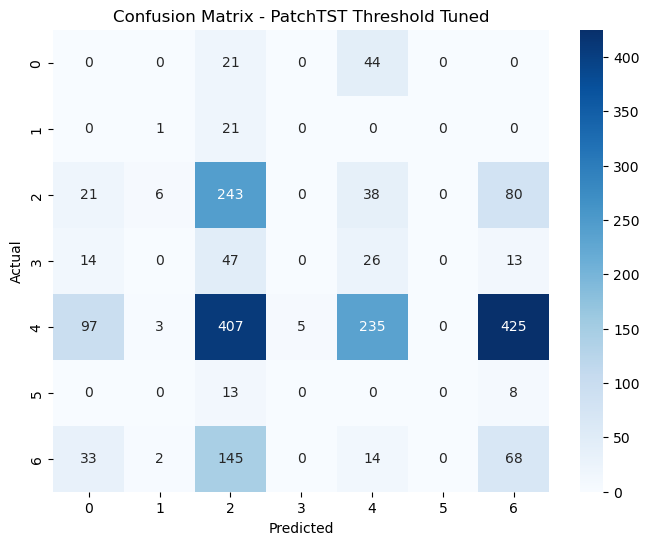

In [36]:
# confusion matrix for the tuned predictions
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_true, y_test_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - PatchTST Threshold Tuned")
plt.show()

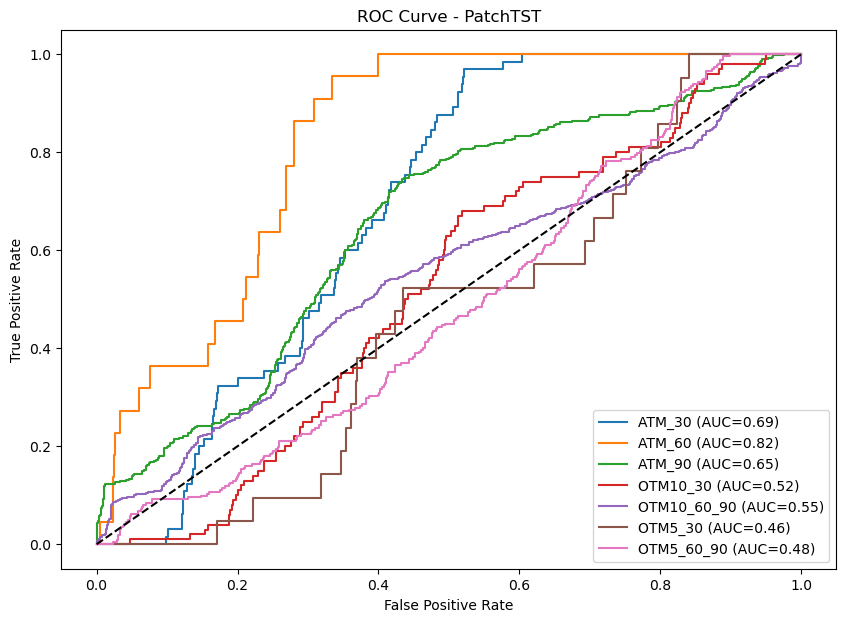

In [37]:
# ROC-AUC curves
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_true_bin = label_binarize(y_test_true, classes=range(num_classes))

plt.figure(figsize=(10, 7))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_true_bin[:, i], y_test_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{target_encoder.classes_[i]} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PatchTST")
plt.legend()
plt.show()

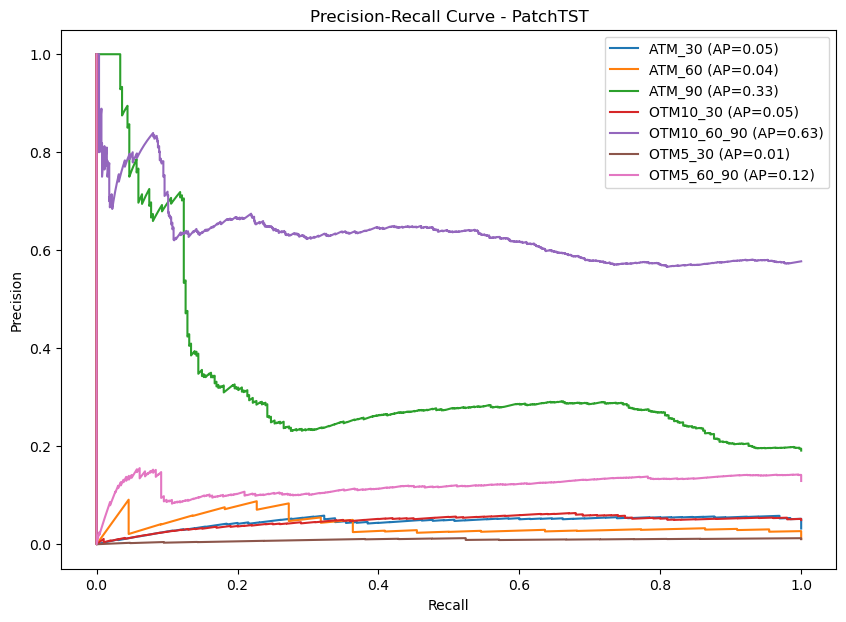

In [38]:
# Precesion recall curves
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_test_true_bin[:, i], y_test_prob[:, i])
    ap = average_precision_score(y_test_true_bin[:, i], y_test_prob[:, i])
    plt.plot(recall, precision, label=f"{target_encoder.classes_[i]} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - PatchTST")
plt.legend()
plt.show()

### improved tuning cell on validation only

In [39]:
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

def predict_with_class_thresholds(prob_array, thresholds):
    adjusted = prob_array / thresholds.reshape(1, -1)
    return adjusted.argmax(axis=1)

search_space = {
    0: [0.25, 0.35, 0.45, 0.55, 0.65],   # ATM_30
    1: [0.25, 0.35, 0.45, 0.55, 0.65],   # ATM_60
    2: [0.80, 1.00, 1.20, 1.40],         # ATM_90
    3: [0.15, 0.35, 0.45, 0.55, 0.65],   # OTM10_30
    4: [0.50, 0.60, 0.75, 0.90, 1.10],   # OTM10_60_90
    5: [0.15, 0.35, 0.45, 0.55, 0.65],   # OTM5_30
    6: [1.00, 1.20, 1.40, 1.60, 1.80]    # OTM5_60_90
}


thresholds = np.ones(y_val_prob.shape[1])

best_score = f1_score(
    y_val_true,
    predict_with_class_thresholds(y_val_prob, thresholds),
    average="macro",
    zero_division=0
)

print("Initial validation Macro F1:", best_score)

improved = True
round_num = 1

while improved:
    improved = False
    print(f"\nRound {round_num}")

    for cls in range(y_val_prob.shape[1]):
        best_t = thresholds[cls]
        best_cls_score = best_score

        for t in search_space[cls]:
            temp_thresholds = thresholds.copy()
            temp_thresholds[cls] = t

            temp_pred = predict_with_class_thresholds(y_val_prob, temp_thresholds)
            temp_score = f1_score(
                y_val_true,
                temp_pred,
                average="macro",
                zero_division=0
            )

            if temp_score > best_cls_score:
                best_cls_score = temp_score
                best_t = t

        if best_t != thresholds[cls]:
            thresholds[cls] = best_t
            best_score = best_cls_score
            improved = True
            print(f"Class {cls} threshold updated to {best_t}, Macro F1={best_score:.6f}")

    round_num += 1

print("\nFinal thresholds:", thresholds)
print("Best validation Macro F1:", best_score)

threshold_df = pd.DataFrame({
    "class_id": range(len(target_encoder.classes_)),
    "class_name": target_encoder.classes_,
    "threshold": thresholds
})

print(threshold_df)

Initial validation Macro F1: 0.16883233115728716

Round 1
Class 0 threshold updated to 0.55, Macro F1=0.176230
Class 2 threshold updated to 0.8, Macro F1=0.178936
Class 4 threshold updated to 0.5, Macro F1=0.183327
Class 6 threshold updated to 1.8, Macro F1=0.191191

Round 2
Class 0 threshold updated to 0.45, Macro F1=0.192074
Class 5 threshold updated to 0.65, Macro F1=0.192122

Round 3

Final thresholds: [0.45 1.   0.8  1.   0.5  0.65 1.8 ]
Best validation Macro F1: 0.19212187017490567
   class_id   class_name  threshold
0         0       ATM_30       0.45
1         1       ATM_60       1.00
2         2       ATM_90       0.80
3         3     OTM10_30       1.00
4         4  OTM10_60_90       0.50
5         5      OTM5_30       0.65
6         6   OTM5_60_90       1.80


In [40]:
y_test_pred_tuned = predict_with_class_thresholds(y_test_prob, thresholds)

In [41]:
from sklearn.metrics import classification_report, f1_score, accuracy_score, balanced_accuracy_score

print("\n=== TEST (Final Threshold Tuned) ===")

print("Accuracy:", accuracy_score(y_test_true, y_test_pred_tuned))
print("Macro F1:", f1_score(y_test_true, y_test_pred_tuned, average="macro"))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_true, y_test_pred_tuned))

print(classification_report(y_val_true, y_val_pred_base, zero_division=0))
print(classification_report(y_test_true, y_test_pred_base, zero_division=0))
print(classification_report(y_test_true, y_test_pred_tuned, zero_division=0))


=== TEST (Final Threshold Tuned) ===
Accuracy: 0.2738916256157635
Macro F1: 0.13220841886503928
Balanced Accuracy: 0.16609340948202037
              precision    recall  f1-score   support

           0       0.22      0.06      0.10       393
           1       0.00      0.01      0.00       159
           2       0.68      0.56      0.62      1891
           3       0.00      0.00      0.00       152
           4       0.42      0.07      0.12      1232
           5       0.00      0.00      0.00        43
           6       0.22      0.77      0.34       650

    accuracy                           0.37      4520
   macro avg       0.22      0.21      0.17      4520
weighted avg       0.45      0.37      0.35      4520

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        65
           1       0.09      0.27      0.13        22
           2       0.27      0.60      0.38       388
           3       0.00      0.00      0.00       